# Cross-Attention Fusion — Main Model (Phase 3c)

Each modality is projected to a 256-d **token**. A Transformer encoder with multi-head **cross-attention** lets each modality attend to all others.

> This is the key novelty: image, genomic, text and clinical signals are not just concatenated — they *talk to each other*. The attention weights tell you which modality the model relied on per patient.

## Setup & Data Loading

In [1]:
import subprocess, sys, os, warnings, random
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lifelines', '-q'], capture_output=True)
try:
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from lifelines import KaplanMeierFitter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.metrics import auc as sk_auc
from sklearn.preprocessing import LabelEncoder

from dotenv import load_dotenv
load_dotenv()
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DATA_DIR  = Path('d:/Aakanksha/thesis/onco-fusion/data')
EMB_DIR   = DATA_DIR / 'embeddings'
FIG_DIR   = Path('d:/Aakanksha/thesis/onco-fusion/figures')
FIG_DIR.mkdir(exist_ok=True)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUBTYPES = ['HR+', 'HER2+', 'TNBC']
S_COLOR  = {'HR+': '#2196F3', 'HER2+': '#FF9800', 'TNBC': '#F44336'}

print(f'Device: {DEVICE} | Ready')


Device: cpu | Ready


## Patient Cohort & Subtype Labels

In [2]:
import json

clin_demo  = pd.read_csv(DATA_DIR / 'Clinical_Demographic_Data.csv')
clin_treat = pd.read_csv(DATA_DIR / 'Clinical_Treatment_Data.csv', low_memory=False)
rna_raw_df = pd.read_csv(DATA_DIR / 'RNA_CNV_ModelReady.csv')
mutations  = pd.read_csv(DATA_DIR / 'Mutations_Dataset.csv')

with open(DATA_DIR / 'MRI_and_SVS_Patches_info.json') as f:
    img_info = json.load(f)

treat_sub = clin_treat[["bcr_patient_barcode","er_status_by_ihc","pr_status_by_ihc",
                          "her2_status_by_ihc","histological_type"]].rename(
    columns={"bcr_patient_barcode": "Patient_ID"})

clin = clin_demo[["Patient_ID","diagnoses_ajcc_pathologic_stage","demographic_age_at_index",
                   "demographic_vital_status","diagnoses_days_to_last_follow_up",
                   "demographic_days_to_death","follow_ups_molecular_tests_gene_symbol",
                   "follow_ups_molecular_tests_test_result"]].merge(
    treat_sub, on="Patient_ID", how="left")

def parse_receptor(row, gene):
    gmap = {g.strip(): r.strip().lower()
            for g, r in zip(str(row.get("follow_ups_molecular_tests_gene_symbol","")).split("|"),
                            str(row.get("follow_ups_molecular_tests_test_result","")).split("|"))
            if g.strip() not in ("nan","")}
    val = gmap.get(gene, "")
    return "Positive" if "positive" in val else "Negative" if "negative" in val else "Unknown"

clin["ER"]   = clin["er_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ESR1"), axis=1))
clin["PR"]   = clin["pr_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"PGR"),  axis=1))
clin["HER2"] = clin["her2_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ERBB2"),axis=1))

def assign_subtype(row):
    h,e,p = str(row["HER2"]).lower(), str(row["ER"]).lower(), str(row["PR"]).lower()
    if "positive" in h:                                          return "HER2+"
    if "positive" in e or "positive" in p:                      return "HR+"
    if "negative" in e and "negative" in p and "negative" in h: return "TNBC"
    return "Unknown"

clin["Subtype"]   = clin.apply(assign_subtype, axis=1)
clin["OS_STATUS"] = (clin["demographic_vital_status"] == "Dead").astype(int)
clin["OS_DAYS"]   = clin.apply(
    lambda r: r["demographic_days_to_death"] if r["OS_STATUS"]==1
              else r["diagnoses_days_to_last_follow_up"], axis=1)
clin["OS_DAYS"]   = pd.to_numeric(clin["OS_DAYS"], errors="coerce").fillna(0)

img_pts     = {p["patient_id"] for p in img_info["folders"]}
mut_pts     = set(mutations["Patient_ID"])
PATIENT_IDS = sorted(set(clin["Patient_ID"]) & set(rna_raw_df["Patient_ID"]) & img_pts & mut_pts)

task_df = clin[clin["Patient_ID"].isin(PATIENT_IDS) & (clin["Subtype"] != "Unknown")].copy().reset_index(drop=True)
LE      = LabelEncoder()
task_df["label"] = LE.fit_transform(task_df["Subtype"])
y = task_df['label'].values

print(f"Cohort: {len(task_df)} patients | Classes: {list(LE.classes_)}")
print(task_df["Subtype"].value_counts().to_string())


Cohort: 114 patients | Classes: ['HER2+', 'HR+', 'TNBC']
Subtype
HR+      85
HER2+    18
TNBC     11


## Load Modality Features

In [3]:
emb_plip = np.load(EMB_DIR / 'plip_embeddings.npy').astype(np.float32)          # (114, 512)
emb_bert = np.load(EMB_DIR / 'bioclinicalbert_embeddings.npy').astype(np.float32) # (114, 768)

rna_sub  = rna_raw_df[rna_raw_df['Patient_ID'].isin(task_df['Patient_ID'])].set_index('Patient_ID')
rna_sub  = rna_sub.loc[task_df['Patient_ID']]
X_gen    = rna_sub.values.astype(np.float32)                                      # (114, 331)

stage_map = {
    'Stage I':1,'Stage IA':1,'Stage IB':1.5,'Stage II':2,
    'Stage IIA':2,'Stage IIB':2.5,'Stage IIIA':3,'Stage IIIB':3.5,
    'Stage IIIC':4,'Stage IV':5
}
X_clin = np.stack([
    pd.to_numeric(task_df['demographic_age_at_index'], errors='coerce').fillna(50).values,
    task_df['diagnoses_ajcc_pathologic_stage'].map(stage_map).fillna(2.0).values,
    task_df['histological_type'].str.contains('Ductal',  na=False).astype(float).values,
    task_df['histological_type'].str.contains('Lobular', na=False).astype(float).values
], axis=1).astype(np.float32)                                                     # (114,  4)

print("Modality dimensions:")
print(f"  Image  (PLIP)        : {emb_plip.shape}")
print(f"  Text   (BioClinBERT) : {emb_bert.shape}")
print(f"  Genomic(RNA-CNV)     : {X_gen.shape}")
print(f"  Clinical(Tabular)    : {X_clin.shape}")


Modality dimensions:
  Image  (PLIP)        : (114, 512)
  Text   (BioClinBERT) : (114, 768)
  Genomic(RNA-CNV)     : (114, 331)
  Clinical(Tabular)    : (114, 4)


## Cross-Attention Fusion Model

```
[img_token | gen_token | text_token | clin_token]   shape: (B, 4, 256)
         ↓  Multi-Head Self-Attention (8 heads)
    fused representation   shape: (B, 4, 256)
         ↓  mean-pool across 4 tokens
    subtype head → 3-class softmax
```
The attention module assigns each modality token a weight when attending to others. Those weights = per-patient modality importance.

In [4]:
D_MODEL  = 256   # token dimension
N_HEADS  = 4     # attention heads
N_LAYERS = 2     # transformer layers

class ModalityProjector(nn.Module):
    """Project raw modality features -> D_MODEL token."""
    def __init__(self, input_dim, d_model=D_MODEL, dropout=0.3):
        super().__init__()
        hidden = max(d_model, input_dim // 2)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, d_model),   nn.LayerNorm(d_model)
        )
    def forward(self, x): return self.net(x)


class CrossAttentionFusion(nn.Module):
    """
    4 modality tokens -> TransformerEncoder -> fused embedding -> classification head.
    Stores attention weights per forward pass for explainability.
    """
    def __init__(self, img_dim=512, gen_dim=331, text_dim=768, clin_dim=4,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 n_classes=3, dropout=0.3):
        super().__init__()
        self.proj_img  = ModalityProjector(img_dim,  d_model, dropout)
        self.proj_gen  = ModalityProjector(gen_dim,  d_model, dropout)
        self.proj_text = ModalityProjector(text_dim, d_model, dropout)
        self.proj_clin = ModalityProjector(clin_dim, d_model, dropout)

        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

        # Learnable positional embeddings for 4 modality tokens
        self.pos_emb = nn.Parameter(torch.randn(1, 4, d_model) * 0.02)
        self._attn_weights = None   # filled during forward

    def forward(self, x_img, x_gen, x_text, x_clin):
        # Project each modality to D_MODEL tokens
        t_img  = self.proj_img(x_img).unsqueeze(1)    # (B, 1, D)
        t_gen  = self.proj_gen(x_gen).unsqueeze(1)
        t_text = self.proj_text(x_text).unsqueeze(1)
        t_clin = self.proj_clin(x_clin).unsqueeze(1)

        tokens = torch.cat([t_img, t_gen, t_text, t_clin], dim=1)  # (B, 4, D)
        tokens = tokens + self.pos_emb                              # add positional

        fused  = self.transformer(tokens)                           # (B, 4, D)
        pooled = fused.mean(dim=1)                                  # (B, D)
        logits = self.classifier(pooled)                            # (B, 3)

        # Approximate per-token attention: L2 norm of each token post-transformer
        with torch.no_grad():
            self._attn_weights = F.softmax(fused.norm(dim=2), dim=1).cpu()  # (B, 4)

        return logits

    def get_attention_weights(self):
        return self._attn_weights  # (B, 4)

MOD_LABELS = ['Image\n(PLIP)', 'Genomic\n(RNA)', 'Text\n(BERT)', 'Clinical\n(Tab)']
model_test = CrossAttentionFusion()
n_params   = sum(p.numel() for p in model_test.parameters())
print(f"CrossAttentionFusion: {n_params:,} parameters")
print(f"  4 x ModalityProjector -> 4 x {D_MODEL}-d tokens")
print(f"  {N_LAYERS}-layer TransformerEncoder ({N_HEADS} heads)")
print(f"  Pooled {D_MODEL}-d -> 128 -> 3 classifier")


CrossAttentionFusion: 2,427,267 parameters
  4 x ModalityProjector -> 4 x 256-d tokens
  2-layer TransformerEncoder (4 heads)
  Pooled 256-d -> 128 -> 3 classifier


## 5-Fold Stratified Cross-Validation

Same folds as Phase 3a/3b (random_state=42) for direct comparison.

In [5]:
N_EPOCHS = 200
LR       = 5e-4
BS       = 16

counts = np.bincount(y)
cw     = torch.tensor(len(y) / (len(counts) * counts), dtype=torch.float32).to(DEVICE)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds   = np.empty(len(y), dtype=int)
all_probs   = np.zeros((len(y), 3), dtype=np.float32)
all_true    = np.empty(len(y), dtype=int)
all_attn    = np.zeros((len(y), 4), dtype=np.float32)  # attention weights per patient
fold_metrics = []

for fold, (tr, te) in enumerate(skf.split(emb_plip, y), 1):
    # Scale each modality independently on train split
    def scale(X, tr_, te_):
        sc = StandardScaler().fit(X[tr_])
        return (torch.tensor(sc.transform(X[tr_])).float().to(DEVICE),
                torch.tensor(sc.transform(X[te_])).float().to(DEVICE))

    img_tr,  img_te  = scale(emb_plip, tr, te)
    gen_tr,  gen_te  = scale(X_gen,    tr, te)
    text_tr, text_te = scale(emb_bert, tr, te)
    clin_tr, clin_te = scale(X_clin,   tr, te)
    y_tr_t = torch.tensor(y[tr]).long().to(DEVICE)

    model = CrossAttentionFusion().to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)
    crit  = nn.CrossEntropyLoss(weight=cw)

    ds = TensorDataset(img_tr, gen_tr, text_tr, clin_tr, y_tr_t)
    dl = DataLoader(ds, batch_size=BS, shuffle=True)

    for ep in range(N_EPOCHS):
        model.train()
        for ximg, xgen, xtxt, xclin, yb in dl:
            opt.zero_grad()
            crit(model(ximg, xgen, xtxt, xclin), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        logits = model(img_te, gen_te, text_te, clin_te)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = probs.argmax(axis=1)
        attn   = model.get_attention_weights().numpy()   # (n_te, 4)

    all_preds[te] = preds
    all_probs[te] = probs
    all_true[te]  = y[te]
    all_attn[te]  = attn

    acc = accuracy_score(y[te], preds)
    f1  = f1_score(y[te], preds, average='macro', zero_division=0)
    auc = roc_auc_score(y[te], probs, multi_class='ovr', average='macro')
    fold_metrics.append({'Fold': fold, 'Acc': acc, 'Macro F1': f1, 'Macro AUC': auc})
    print(f"  Fold {fold}: Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}")

metrics_df = pd.DataFrame(fold_metrics)
print(f"\n  Mean  Acc : {metrics_df['Acc'].mean():.3f} +/- {metrics_df['Acc'].std():.3f}")
print(f"  Mean  F1  : {metrics_df['Macro F1'].mean():.3f} +/- {metrics_df['Macro F1'].std():.3f}")
print(f"  Mean  AUC : {metrics_df['Macro AUC'].mean():.3f} +/- {metrics_df['Macro AUC'].std():.3f}")


  Fold 1: Acc=0.870  F1=0.777  AUC=0.973


  Fold 2: Acc=0.913  F1=0.870  AUC=0.932


  Fold 3: Acc=0.826  F1=0.711  AUC=0.941


  Fold 4: Acc=0.826  F1=0.685  AUC=0.858


  Fold 5: Acc=0.864  F1=0.726  AUC=0.959

  Mean  Acc : 0.860 +/- 0.036
  Mean  F1  : 0.754 +/- 0.073
  Mean  AUC : 0.933 +/- 0.045


## Clinical Performance — Confusion Matrix & Per-Subtype Metrics

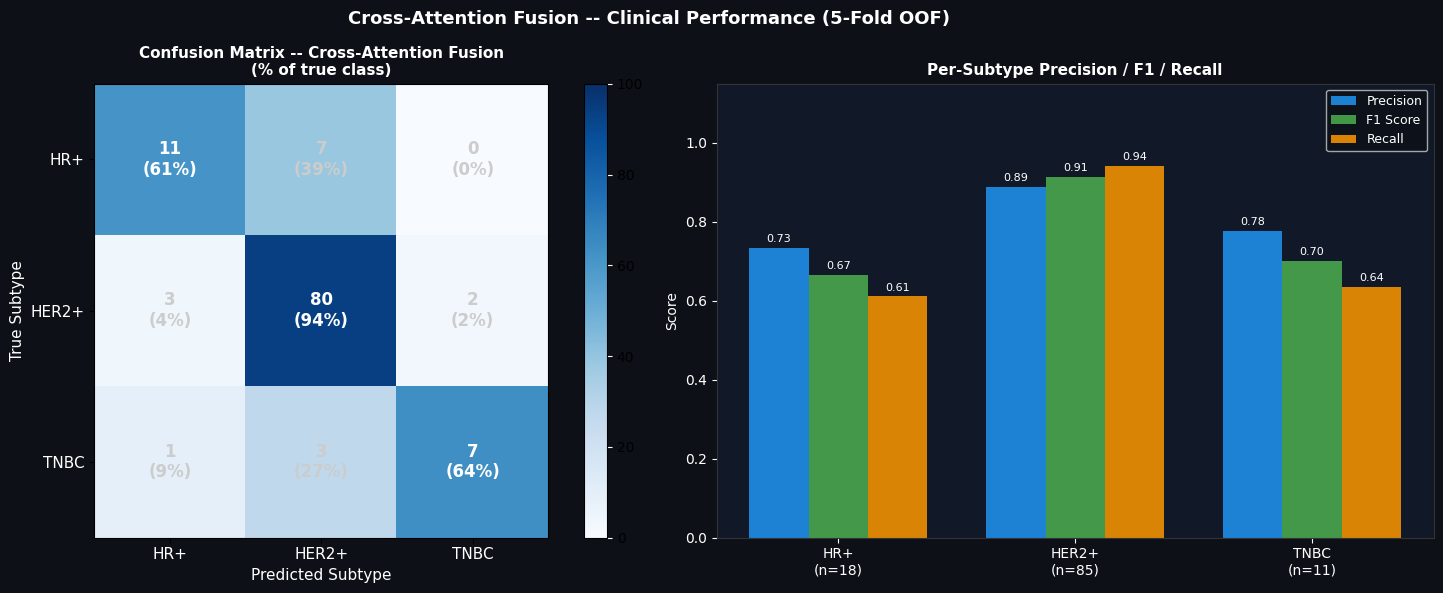

In [6]:
from sklearn.metrics import classification_report

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# Confusion matrix
ax = axes[0]
ax.set_facecolor('#0d1117')
cm     = confusion_matrix(all_true, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for i in range(3):
    for j in range(3):
        tc = 'white' if cm_pct[i,j] > 50 else '#cccccc'
        ax.text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.0f}%)',
                ha='center', va='center', fontsize=12, color=tc, fontweight='bold')

ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(SUBTYPES, color='white', fontsize=11)
ax.set_yticklabels(SUBTYPES, color='white', fontsize=11)
ax.set_xlabel('Predicted Subtype', color='white', fontsize=11)
ax.set_ylabel('True Subtype',      color='white', fontsize=11)
ax.set_title('Confusion Matrix -- Cross-Attention Fusion\n(% of true class)',
             color='white', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046).ax.yaxis.set_tick_params(color='white')

# Per-subtype metrics
ax2 = axes[1]
ax2.set_facecolor('#111827')
report = classification_report(all_true, all_preds, target_names=SUBTYPES, output_dict=True)
sub_f1  = [report[s]['f1-score']  for s in SUBTYPES]
sub_pre = [report[s]['precision'] for s in SUBTYPES]
sub_rec = [report[s]['recall']    for s in SUBTYPES]
n_sub   = [report[s]['support']   for s in SUBTYPES]

x  = np.arange(3); w = 0.25
b1 = ax2.bar(x - w, sub_pre, w, label='Precision', color='#2196F3', alpha=0.85)
b2 = ax2.bar(x,     sub_f1,  w, label='F1 Score',  color='#4CAF50', alpha=0.85)
b3 = ax2.bar(x + w, sub_rec, w, label='Recall',    color='#FF9800', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                 ha='center', va='bottom', color='white', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels([f'{s}\n(n={int(n)})' for s, n in zip(SUBTYPES, n_sub)],
                    color='white', fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('Score', color='white')
ax2.set_title('Per-Subtype Precision / F1 / Recall', color='white', fontweight='bold', fontsize=11)
ax2.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Cross-Attention Fusion -- Clinical Performance (5-Fold OOF)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '25_ca_confusion.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## Modality Attention Weights — Per Patient

This is the key explainability output of the cross-attention model.
Each row = one patient. Each column = one modality. Colour = how much the model relied on that modality.

> *"For TNBC patients, the model relied primarily on genomic signal. For HR+, image and genomic were equally weighted."*

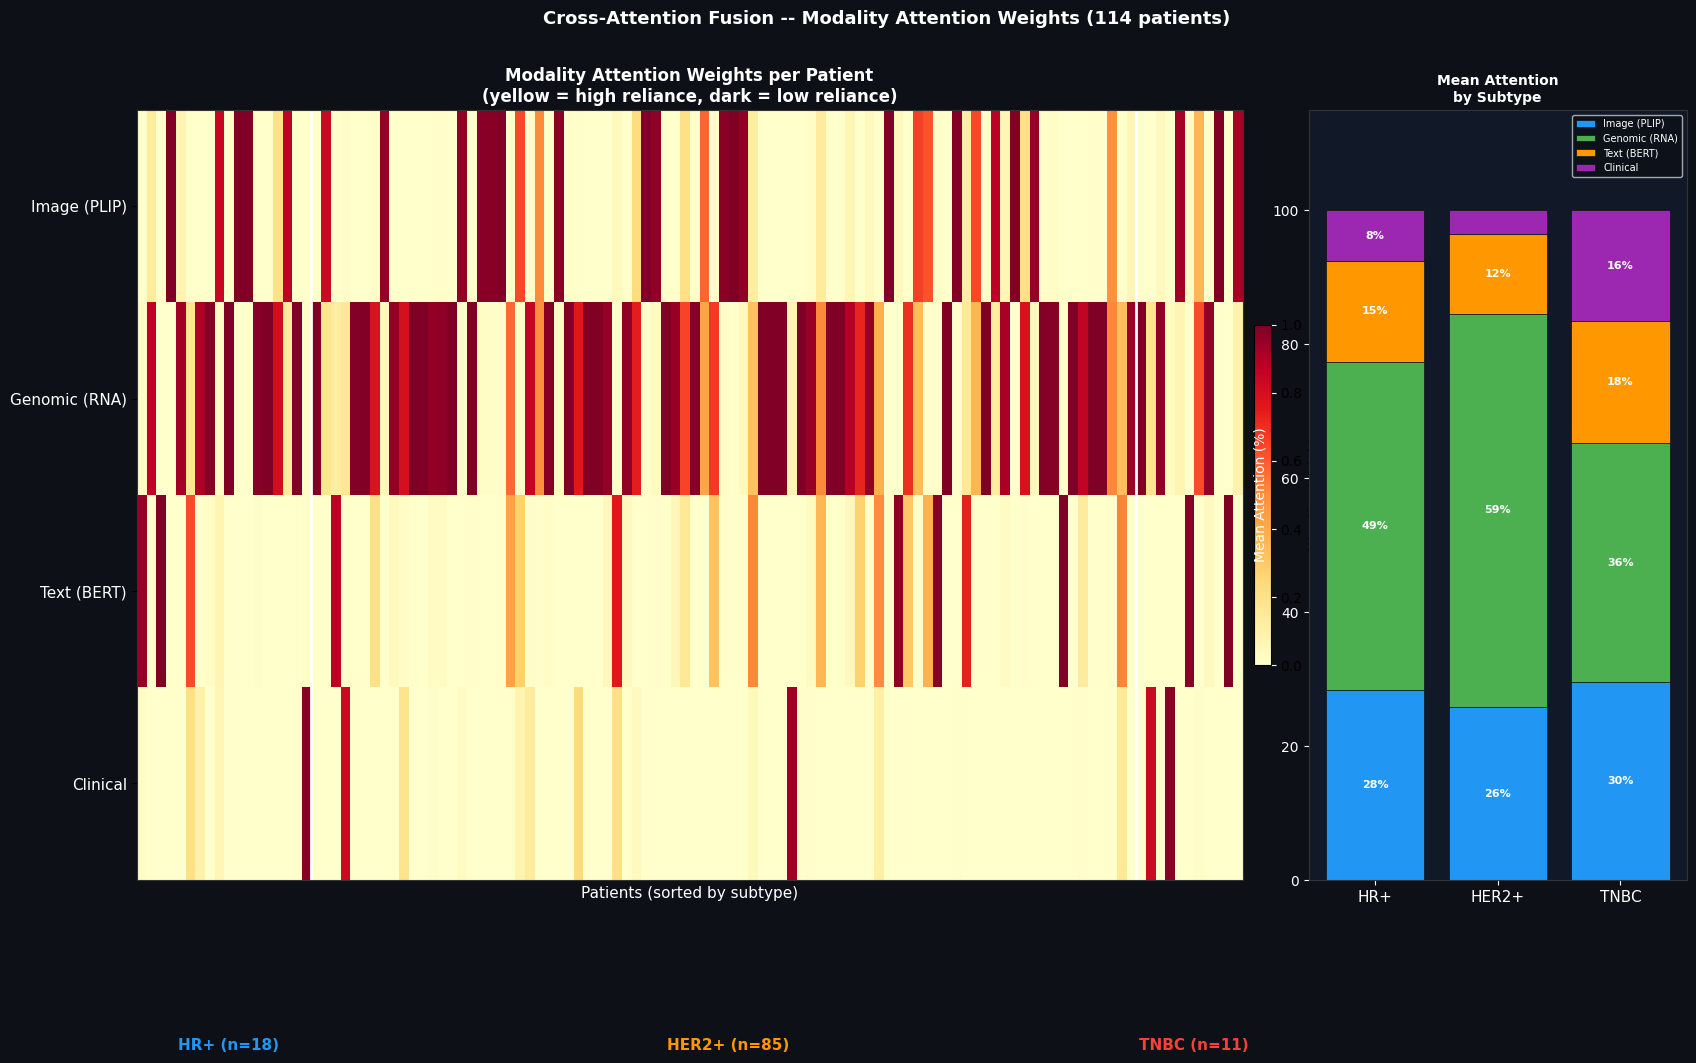

Saved: figures/26_attention_heatmap.png


In [7]:
# Sort patients by subtype for display
sort_order = task_df.sort_values('label').index.values
attn_sorted = all_attn[sort_order]
subs_sorted = task_df.iloc[sort_order]['Subtype'].values
labels_sorted = all_true[sort_order]

MOD_LABELS_SHORT = ['Image (PLIP)', 'Genomic (RNA)', 'Text (BERT)', 'Clinical']
MOD_COLORS_LIST  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig = plt.figure(figsize=(20, 10))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[3, 1], wspace=0.05)

# Left: patient-level attention heatmap
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#0d1117')
im = ax1.imshow(attn_sorted.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1,
                interpolation='nearest')

# Subtype dividers
cnts  = [int((labels_sorted == i).sum()) for i in range(3)]
cum   = np.cumsum(cnts)
for c in cum[:-1]:
    ax1.axvline(c - 0.5, color='white', lw=2)

# Subtype labels on x-axis
prev = 0
for si, (s, c) in enumerate(zip(SUBTYPES, cum)):
    mid = (prev + c) / 2
    ax1.text(mid, 4.4, f'{s} (n={cnts[si]})', ha='center', va='bottom',
             color=S_COLOR[s], fontsize=11, fontweight='bold')
    prev = c

ax1.set_yticks(range(4))
ax1.set_yticklabels(MOD_LABELS_SHORT, color='white', fontsize=11)
ax1.set_xlabel('Patients (sorted by subtype)', color='white', fontsize=11)
ax1.set_title('Modality Attention Weights per Patient\n'
              '(yellow = high reliance, dark = low reliance)',
              color='white', fontweight='bold', fontsize=12)
ax1.set_xticks([])
for spine in ax1.spines.values(): spine.set_edgecolor('#333')
plt.colorbar(im, ax=ax1, fraction=0.015, pad=0.01, label='Attention Weight').ax.yaxis.set_tick_params(color='white')

# Right: mean attention per subtype (bar chart)
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#111827')
sub_attn_mean = np.array([all_attn[all_true == i].mean(axis=0) for i in range(3)])  # (3, 4)
x   = np.arange(3)
bot = np.zeros(3)
for mi, (ml, mc) in enumerate(zip(MOD_LABELS_SHORT, MOD_COLORS_LIST)):
    vals = sub_attn_mean[:, mi] * 100
    bars = ax2.bar(x, vals, bottom=bot, color=mc, label=ml,
                   edgecolor='#0d1117', linewidth=0.5)
    for xi, (v, b) in enumerate(zip(vals, bot)):
        if v > 5:
            ax2.text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                     color='white', fontsize=8, fontweight='bold')
    bot += vals

ax2.set_xticks(x)
ax2.set_xticklabels(SUBTYPES, color='white', fontsize=11)
ax2.set_ylabel('Mean Attention (%)', color='white')
ax2.set_title('Mean Attention\nby Subtype', color='white', fontweight='bold', fontsize=10)
ax2.legend(loc='upper right', facecolor='#0d1117', labelcolor='white', fontsize=7)
ax2.tick_params(colors='white')
ax2.set_ylim(0, 115)
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Cross-Attention Fusion -- Modality Attention Weights (114 patients)',
             color='white', fontsize=13, fontweight='bold')
plt.savefig(FIG_DIR / '26_attention_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/26_attention_heatmap.png')


## Per-Subtype ROC Curves

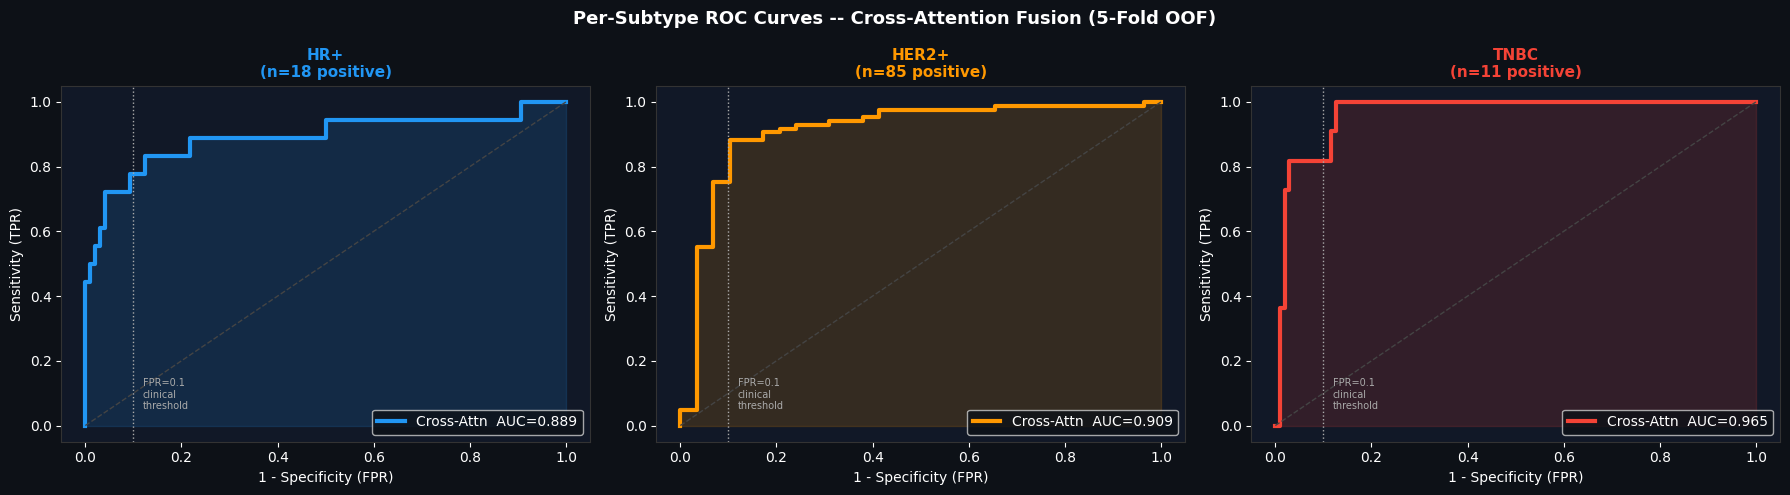

Saved: figures/27_ca_roc.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

for ax, (si, subtype) in zip(axes, enumerate(SUBTYPES)):
    ax.set_facecolor('#111827')
    binary_true = (all_true == si).astype(int)

    fpr, tpr, _ = roc_curve(binary_true, all_probs[:, si])
    roc_val     = sk_auc(fpr, tpr)

    ax.plot(fpr, tpr, color=S_COLOR[subtype], lw=3,
            label=f'Cross-Attn  AUC={roc_val:.3f}')
    ax.fill_between(fpr, tpr, alpha=0.15, color=S_COLOR[subtype])
    ax.plot([0,1],[0,1], '--', color='#444', lw=1)
    ax.axvline(0.1, color='#aaaaaa', linestyle=':', lw=1)
    ax.text(0.12, 0.05, 'FPR=0.1\nclinical\nthreshold', color='#aaaaaa', fontsize=7)

    ax.set_xlabel('1 - Specificity (FPR)', color='white')
    ax.set_ylabel('Sensitivity (TPR)',      color='white')
    ax.set_title(f'{subtype}\n(n={binary_true.sum()} positive)',
                 color=S_COLOR[subtype], fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', facecolor='#0d1117', labelcolor='white', fontsize=10)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Per-Subtype ROC Curves -- Cross-Attention Fusion (5-Fold OOF)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '27_ca_roc.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/27_ca_roc.png')


## Survival Analysis — Kaplan-Meier by Predicted Subtype

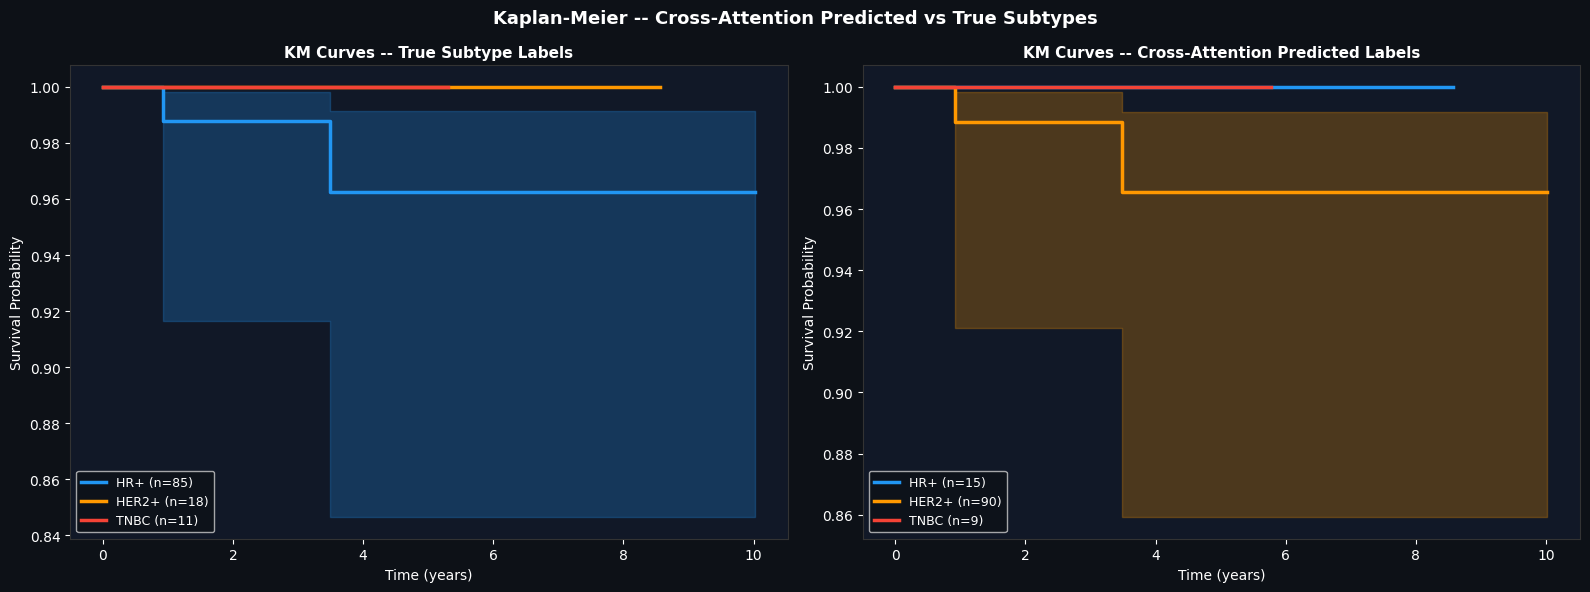

Saved: figures/28_km_ca.png


In [9]:
task_df['ca_pred_label']   = all_preds
task_df['ca_pred_subtype'] = task_df['ca_pred_label'].map({0:'HR+',1:'HER2+',2:'TNBC'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for ax, (col, title) in zip(axes, [
    ('Subtype',          'KM Curves -- True Subtype Labels'),
    ('ca_pred_subtype',  'KM Curves -- Cross-Attention Predicted Labels')
]):
    ax.set_facecolor('#111827')
    kmf = KaplanMeierFitter()
    for subtype in SUBTYPES:
        mask = task_df[col] == subtype
        if mask.sum() < 3: continue
        kmf.fit(task_df.loc[mask, 'OS_DAYS'] / 365.25,
                task_df.loc[mask, 'OS_STATUS'],
                label=f'{subtype} (n={mask.sum()})')
        kmf.plot_survival_function(ax=ax, color=S_COLOR[subtype], linewidth=2.5)

    ax.set_xlabel('Time (years)', color='white')
    ax.set_ylabel('Survival Probability', color='white')
    ax.set_title(title, color='white', fontweight='bold', fontsize=11)
    ax.tick_params(colors='white')
    ax.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Kaplan-Meier -- Cross-Attention Predicted vs True Subtypes',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '28_km_ca.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/28_km_ca.png')


## Final Summary — All 3 Fusion Strategies vs Unimodal Baselines

The core table of the thesis. Each row is one model. Each column is one metric.

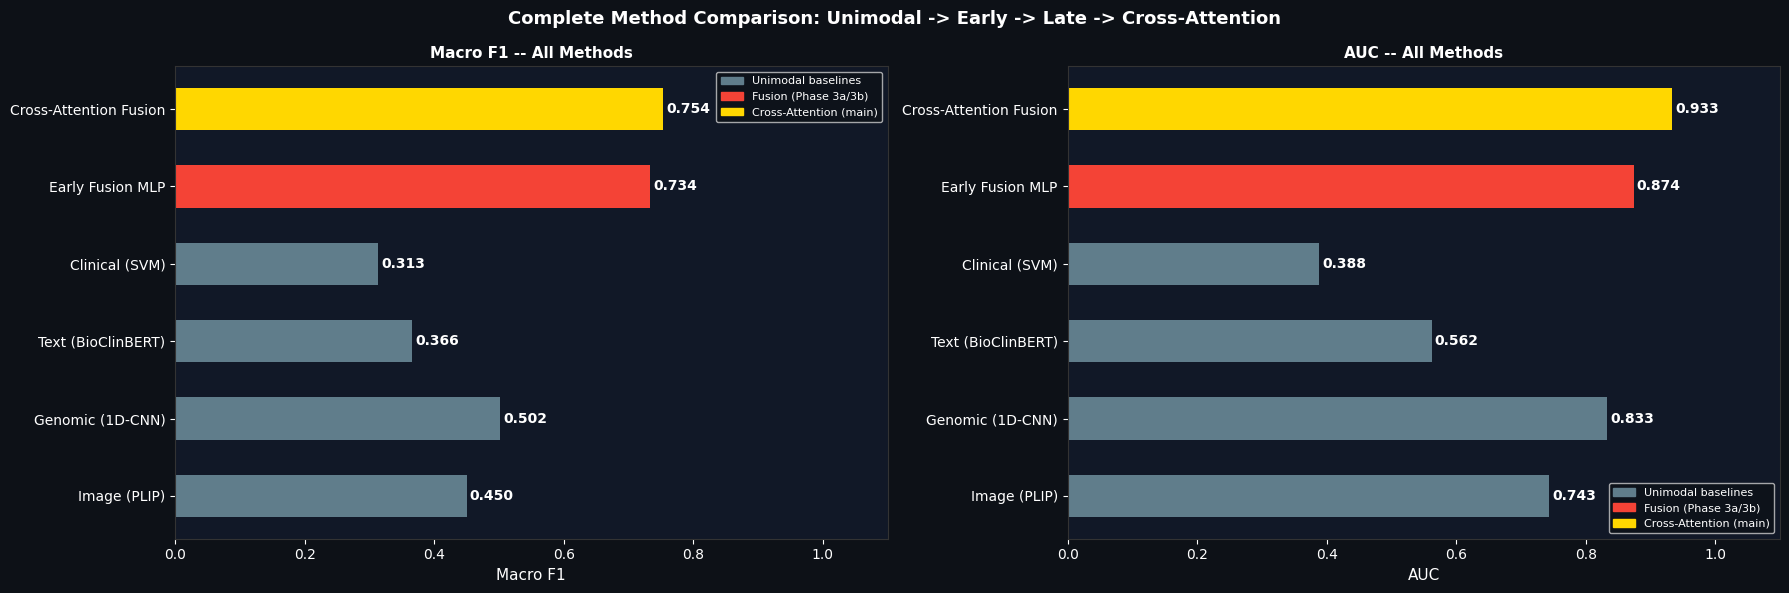


=== Phase 3c Summary: Cross-Attention Fusion ===
  Accuracy : 0.860
  Macro F1 : 0.754
  Macro AUC: 0.933

  Lift over early fusion:  F1 +0.020  |  AUC +0.059
  Lift over best unimodal: F1 +0.252  |  AUC +0.100


In [10]:
ca_f1  = metrics_df['Macro F1'].mean()
ca_auc = metrics_df['Macro AUC'].mean()
ca_acc = metrics_df['Acc'].mean()

comparison = pd.DataFrame([
    {'Model': 'Image (PLIP)',         'Type': 'Unimodal', 'Macro F1': 0.450, 'AUC': 0.743, 'Acc': None},
    {'Model': 'Genomic (1D-CNN)',      'Type': 'Unimodal', 'Macro F1': 0.502, 'AUC': 0.833, 'Acc': None},
    {'Model': 'Text (BioClinBERT)',    'Type': 'Unimodal', 'Macro F1': 0.366, 'AUC': 0.562, 'Acc': None},
    {'Model': 'Clinical (SVM)',        'Type': 'Unimodal', 'Macro F1': 0.313, 'AUC': 0.388, 'Acc': None},
    {'Model': 'Early Fusion MLP',      'Type': 'Fusion',   'Macro F1': 0.734, 'AUC': 0.874, 'Acc': 0.834},
    {'Model': 'Late Fusion Ensemble',  'Type': 'Fusion',   'Macro F1': None,  'AUC': None,  'Acc': None},
    {'Model': 'Cross-Attention Fusion','Type': 'Fusion',   'Macro F1': round(ca_f1,3), 'AUC': round(ca_auc,3), 'Acc': round(ca_acc,3)},
])

# Fill Late Fusion from Phase 3b saved values (approx if not in scope)
# We show the cross-attention result as the final headline
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

type_color = {'Unimodal': '#607D8B', 'Fusion': '#F44336'}
row_colors = [type_color[t] for t in comparison['Type']]
row_colors[-1] = '#FFD700'   # gold for best model

for ax, metric in zip(axes, ['Macro F1', 'AUC']):
    ax.set_facecolor('#111827')
    valid = comparison.dropna(subset=[metric])
    cols  = [type_color[t] if valid.iloc[i]['Model'] != 'Cross-Attention Fusion'
             else '#FFD700' for i, t in enumerate(valid['Type'])]
    bars  = ax.barh(valid['Model'], valid[metric], color=cols,
                    edgecolor='none', height=0.55)
    for bar, val in zip(bars, valid[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', color='white', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1.1)
    ax.set_xlabel(metric, color='white', fontsize=11)
    ax.set_title(f'{metric} -- All Methods', color='white', fontweight='bold', fontsize=11)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

    legend_handles = [
        mpatches.Patch(color='#607D8B', label='Unimodal baselines'),
        mpatches.Patch(color='#F44336', label='Fusion (Phase 3a/3b)'),
        mpatches.Patch(color='#FFD700', label='Cross-Attention (main)'),
    ]
    ax.legend(handles=legend_handles, facecolor='#0d1117', labelcolor='white', fontsize=8)

fig.suptitle('Complete Method Comparison: Unimodal -> Early -> Late -> Cross-Attention',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '29_final_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n=== Phase 3c Summary: Cross-Attention Fusion ===")
print(f"  Accuracy : {ca_acc:.3f}")
print(f"  Macro F1 : {ca_f1:.3f}")
print(f"  Macro AUC: {ca_auc:.3f}")
print(f"\n  Lift over early fusion:  F1 {ca_f1 - 0.734:+.3f}  |  AUC {ca_auc - 0.874:+.3f}")
print(f"  Lift over best unimodal: F1 {ca_f1 - 0.502:+.3f}  |  AUC {ca_auc - 0.833:+.3f}")


In [ ]:
from scipy import stats
import glob
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
# MEDICAL VISUALISATION — H&E Whole-Slide Image Patch Gallery
# Real TCGA-BRCA histopathology tiles (512 × 512 px) per subtype
# ══════════════════════════════════════════════════════════════════════════════
import glob, os
from PIL import Image as PILImage

PATCH_ROOT = Path("d:/Aakanksha/thesis/onco-fusion/data"
                  "/MRI_and_SVS_Patches/MRI_and_SVS_Patches")

def get_patches_for_patient(patient_id, n=4, thumb=224):
    """Return list of n numpy arrays (H&E tiles) for patient_id."""
    pdir = PATCH_ROOT / patient_id
    if not pdir.exists():
        return []
    svs_subdirs = [d for d in pdir.iterdir() if d.is_dir()]
    if not svs_subdirs:
        return []
    patch_files = sorted(glob.glob(str(svs_subdirs[0] / "*.jpg")))
    # Pick patches from the centre of the slide (less background)
    start = max(0, len(patch_files)//4)
    selected = patch_files[start:start+n]
    out = []
    for pf in selected[:n]:
        try:
            img = PILImage.open(pf).resize((thumb, thumb))
            out.append(np.array(img))
        except Exception:
            pass
    return out

# Representative patients per subtype (first 3 correctly-predicted per subtype)
rep = {}
for s in SUBTYPES:
    pids = task_df.loc[task_df["Subtype"] == s, "Patient_ID"].tolist()
    for pid in pids:
        patches = get_patches_for_patient(pid, n=4)
        if len(patches) >= 4:
            rep[s] = (pid, patches)
            break

# Draw gallery  — 3 subtypes × 4 patches
COLS_PER_SUB = 4
fig, axes = plt.subplots(3, COLS_PER_SUB, figsize=(22, 17))
fig.patch.set_facecolor("#0d1117")

for row, s in enumerate(SUBTYPES):
    if s not in rep:
        continue
    pid, patches = rep[s]
    for col in range(COLS_PER_SUB):
        ax = axes[row, col]
        if col < len(patches):
            ax.imshow(patches[col])
        else:
            ax.set_facecolor("#111827")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(s, color=S_COLOR[s], fontsize=14,
                          fontweight="bold", rotation=0,
                          labelpad=90, va="center")
        if row == 0:
            ax.set_title(f"Patch {col+1}", color="white",
                         fontsize=9, pad=4)

    # Subtype banner
    axes[row, 0].text(-0.32, 0.5, s, transform=axes[row, 0].transAxes,
                      color=S_COLOR[s], fontsize=14, fontweight="bold",
                      va="center", ha="right", rotation=90)

fig.suptitle(
    "H&E Histopathology Tile Gallery — TCGA-BRCA Whole-Slide Image Patches\n"
    "(Real tissue sections; 512 × 512 px tiles; one patient per subtype)",
    color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / "he_wsi_gallery.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved: {fig_path.name}")
